<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



Note jeremy
Est ce qu'il faut faire le calcul de la sous nutrition sur les pays qu'on a ?
Est ce qu'il faut faire des graphiques ?
Rajouter le soja
La liste des céréales est difficile a trouver ...

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd; import matplotlib.pyplot as plt; import seaborn as sns;


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [2]:
#Importation du fichier population.csv
population = pd.read_csv('population.csv')

#Importation du fichier dispo_alimentaire.csv
dispoAlimentaire = pd.read_csv('dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aideAlimentaire = pd.read_csv('aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sousNutrition = pd.read_csv('sous_nutrition.csv')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [3]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [4]:
#Consulter le nombre de colonnes
print("Le nombre de colonnes : {}".format(population.shape[1]))

#La nature des données dans chacune des colonnes
print("La nature des données : {}".format(population.dtypes))

#Le nombre de valeurs présentes dans chacune des colonnes
population.info()

Le nombre de colonnes : 3
La nature des données : Zone       object
Année       int64
Valeur    float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1416 non-null   object 
 1   Année   1416 non-null   int64  
 2   Valeur  1416 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 33.3+ KB


In [5]:
#Affichage les 5 premières lignes de la table
population.head(5)

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [6]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population["Valeur"] *= 1000

In [7]:
#changement du nom de la colonne Valeur par Population
population = population.rename(columns = {"Valeur" : "Population"})

In [8]:
#Affichage les 5 premières lignes de la table pour voir les modifications
display(population.head(5))

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [9]:
#Afficher les dimensions du dataset
print("Le tableau a {obs} observation(s) et {col} variable(s) respectivement".format(obs=dispoAlimentaire.shape[0], col=dispoAlimentaire.shape[1]))


Le tableau a 15605 observation(s) et 18 variable(s) respectivement


In [10]:
#Consulter le nombre de colonnes
print("Le tableau a {} variable(s)".format(dispoAlimentaire.shape[1]))

Le tableau a 18 variable(s)


In [11]:
#Affichage les 5 premières lignes de la table
dispoAlimentaire.head(5)


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [12]:
#remplacement des NaN dans le dataset par des 0
dispoAlimentaire.fillna(0,inplace=True)

In [13]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
listeCol = ["Aliments pour animaux","Autres Utilisations","Exportations - Quantité",
            "Importations - Quantité","Nourriture","Pertes","Production","Semences","Traitement","Variation de stock"]

for col in listeCol :
    dispoAlimentaire[col] *= 1000000


In [14]:
#Affichage les 5 premières lignes de la table
display(dispoAlimentaire.head(5))

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [15]:
#Afficher les dimensions du dataset
print("Le tableau a {obs} observations et {col} colonnes".format(obs=aideAlimentaire.shape[0], col=aideAlimentaire.shape[1]))

Le tableau a 1475 observations et 4 colonnes


In [16]:
#Consulter le nombre de colonnes
print("Le tableau a {} variable(s)".format(aideAlimentaire.shape[1]))

Le tableau a 4 variable(s)


In [17]:
#Affichage les 5 premières lignes de la table
display(aideAlimentaire.head(5))

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [18]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aideAlimentaire = aideAlimentaire.rename(columns = {"Pays bénéficiaire" : "Zone"})

In [19]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aideAlimentaire["Valeur"] *= 1000

In [20]:
#Affichage les 5 premières lignes de la table
display(aideAlimentaire.head(5))

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [21]:
#Afficher les dimensions du dataset
print("Le tableau a {} observation(s)".format(sousNutrition.shape[0]))
print("Le tableau a {} variable(s)".format(sousNutrition.shape[1]))

Le tableau a 1218 observation(s)
Le tableau a 3 variable(s)


In [22]:
#Consulter le nombre de colonnes
print("Le tableau a {} variable(s)".format(sousNutrition.shape[1]))

Le tableau a 3 variable(s)


In [23]:
#Afficher les 5 premières lignes de la table
display(sousNutrition.head(5))

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [24]:
#Conversion de la colonne sous nutrition en numérique (si existe des NaN alors problématique => Ajouter un argument : errors="coerce")
sousNutrition['Valeur'] = pd.to_numeric(sousNutrition['Valeur'], errors="coerce")

In [25]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
#Puis remplacement des NaN en 0
sousNutrition.fillna(0,inplace=True)

In [26]:
#changement du nom de la colonne Valeur par sous_nutrition
sousNutrition = sousNutrition.rename(columns = {"Valeur" : "sous_nutrition"})

In [27]:
#Multiplication de la colonne sous_nutrition par 1000000
sousNutrition["sous_nutrition"] *= 1000000

In [28]:
#Afficher les 5 premières lignes de la table
display(sousNutrition.head(5))

,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [29]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
population2017 = population.loc[population["Année"]==2017,:];
sousNutrition2017 = sousNutrition.loc[sousNutrition["Année"]=="2016-2018",:];
popSousNut2017 = pd.merge(population2017, sousNutrition2017, on = "Zone", how = "inner")


In [30]:
#Affichage du dataset
display(popSousNut2017.head(5).sort_values("sous_nutrition"))

,Zone,Année_x,Population,Année_y,sous_nutrition
4,Allemagne,2017,82658409.0,2016-2018,0.0
2,Albanie,2017,2884169.0,2016-2018,100000.0
3,Algérie,2017,41389189.0,2016-2018,1300000.0
1,Afrique du Sud,2017,57009756.0,2016-2018,3100000.0
0,Afghanistan,2017,36296113.0,2016-2018,10500000.0


In [31]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
print("Nombre de personnes en population en 2017 : {:2.1f}".format(popSousNut2017["Population"].sum()))
print("Nombre de personnes en sous-nutrition en 2017 : {:2.1f}".format(popSousNut2017["sous_nutrition"].sum()))

pourcentageSousNut = popSousNut2017["sous_nutrition"].sum()/popSousNut2017["Population"].sum()*100

print("Pourcentage de personne en sous-nutrition en 2017 : {:2.1f}%".format(pourcentageSousNut))


Nombre de personnes en population en 2017 : 7543798779.0
Nombre de personnes en sous-nutrition en 2017 : 535700000.0
Pourcentage de personne en sous-nutrition en 2017 : 7.1%


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [32]:
#Combien mange en moyenne un être humain ? Source => https://nutriandco.com/fr/pages/calcul-apport-calorique-journalier#:~:text=Ce%20qu%27il%20faut%20retenir%20%3A%201%20Officiellement%2C%202100,du%20poids%20%3A%20votre%20poids%20actuel%20x%2025https://nutriandco.com/fr/pages/calcul-apport-calorique-journalier#:~:text=Ce%20qu%27il%20faut%20retenir%20%3A%201%20Officiellement%2C%202100,du%20poids%20%3A%20votre%20poids%20actuel%20x%2025
KcalMoyen = 2400
print("On doit consommer en moyenne: {} kcal chaque jour opour maintenir une bonne santé".format(KcalMoyen))


On doit consommer en moyenne: 2400 kcal chaque jour opour maintenir une bonne santé


In [33]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
popDispoAliment = pd.merge(population2017, dispoAlimentaire, on = "Zone", how="inner")


In [34]:
#Affichage du nouveau dataframe
popDispoAliment.head(5)

,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,2017,36296113.0,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,2017,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,2017,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,2017,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,2017,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


In [35]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
popDispoAliment["dispo_kcal"] = 365*popDispoAliment["Disponibilité alimentaire (Kcal/personne/jour)"]*popDispoAliment["Population"]

print("On dispose: {:,.1f} kcal au niveau mondiale".format(popDispoAliment["dispo_kcal"].sum()))
display(popDispoAliment.head())


On dispose: 7,635,429,388,975,815.0 kcal au niveau mondiale


,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),...,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,dispo_kcal
0,Afghanistan,2017,36296113.0,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,...,53.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,6.624041e+10
1,Afghanistan,2017,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,...,41.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,1.324808e+10
2,Afghanistan,2017,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,...,2.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,1.324808e+10
3,Afghanistan,2017,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00
4,Afghanistan,2017,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,...,82.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,5.299232e+10


In [36]:
#Calcul du nombre d'humains pouvant être nourris
NbPersNourri = popDispoAliment["dispo_kcal"].sum()/(KcalMoyen*365)

print("Le nombre de personne qu'on peut nourrir est de {:,.1f}".format(NbPersNourri))
print("Le nombre de personne qu'on peut nourrir est de {:,.1f}".format(population2017["Population"].sum()))
print("Le pourcentage de personne qu'on peut nourrir est de {:2.1f}%".format(NbPersNourri/population2017["Population"].sum()*100))


Le nombre de personne qu'on peut nourrir est de 8,716,243,594.7
Le nombre de personne qu'on peut nourrir est de 7,548,134,111.0
Le pourcentage de personne qu'on peut nourrir est de 115.5%


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [37]:
#Transfert des données avec les végétaux dans un nouveau dataframe
popDispoAliment_veg = popDispoAliment.loc[popDispoAliment["Origine"]=="vegetale",:]
popDispoAliment_veg.head()

,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),...,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,dispo_kcal
1,Afghanistan,2017,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,...,41.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,1.324808e+10
2,Afghanistan,2017,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,...,2.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,1.324808e+10
3,Afghanistan,2017,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00
4,Afghanistan,2017,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,...,82.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,5.299232e+10
6,Afghanistan,2017,36296113.0,Bière,vegetale,0.0,0.0,0.0,0.09,0.00,...,3.0,0.0,3000000.0,3000000.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00


In [38]:
#Calcul du nombre de kcal disponible pour les végétaux
print("Le nombre de kcal disponible pour les végétaux est de: {:,} kcal".format(popDispoAliment_veg["dispo_kcal"].sum()))

Le nombre de kcal disponible pour les végétaux est de: 6,300,178,937,197,865.0 kcal


In [39]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
NbPersNourri_veg = popDispoAliment_veg["dispo_kcal"].sum()/(KcalMoyen*365)
print("Ces végétaux peuvent nourrir {:,.1f} de personnes".format(NbPersNourri_veg))

print("Le pourcentage de personne qu'on peut nourrir avec les végétaux est de {:2.1f}%".format(NbPersNourri_veg/population2017["Population"].sum()*100))


Ces végétaux peuvent nourrir 7,191,985,088.1 de personnes
Le pourcentage de personne qu'on peut nourrir avec les végétaux est de 95.3%


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [40]:
#Calcul de la disponibilité totale
DispoTotal = popDispoAliment["Importations - Quantité"].sum()-popDispoAliment["Exportations - Quantité"].sum()+popDispoAliment["Production"].sum()+popDispoAliment["Variation de stock"].sum()
    #print("La dispoibilité totale est de : {:,.1f}".format(DispoTotal))

# Une autre manière de calculer la disponibilit" intérieure selon l'équation
DispoTotal2 = popDispoAliment["Nourriture"].sum()+popDispoAliment["Pertes"].sum()+popDispoAliment["Semences"].sum()+popDispoAliment["Traitement"].sum()+popDispoAliment["Aliments pour animaux"].sum()+popDispoAliment["Autres Utilisations"].sum()
print("La dispoibilité intérieure totale est de : {:,.1f} en tonnes".format(DispoTotal2))


La dispoibilité intérieure totale est de : 9,743,539,000,000.0 en tonnes


In [41]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures,
DispCol=[]
LabelCol=["Aliments pour animaux","Pertes","Nourriture","Semences","Traitement","Autres Utilisations"]
for col in LabelCol :
    ptgCol = popDispoAliment[col].sum()/DispoTotal2*100
    print("La disponibilité de {c} est de {p:2.1f}%".format(c=col, p=ptgCol))
    DispCol.append(ptgCol) #incrémenter à la liste de DispCol pour stocker les valeurs trouvées


La disponibilité de Aliments pour animaux est de 13.2%
La disponibilité de Pertes est de 4.6%
La disponibilité de Nourriture est de 49.3%
La disponibilité de Semences est de 1.6%
La disponibilité de Traitement est de 22.4%
La disponibilité de Autres Utilisations est de 8.8%


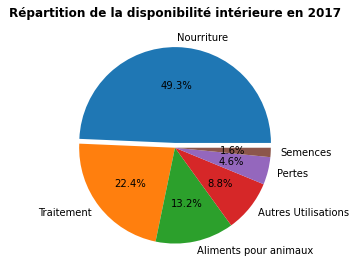

In [42]:
# Création de Camembert

# création de DataFrame pour obtenir construire le Camembert
data = {"Label" : LabelCol, "Dispo" : DispCol}
DispoCol = pd.DataFrame(data).sort_values(by="Dispo", ascending=False) #display(DispoCol)

plt.pie(x=DispoCol["Dispo"], labels = DispoCol["Label"], autopct = "%1.1f%%", explode = (0.05,0,0,0,0,0), shadow=False)
plt.title("Répartition de la disponibilité intérieure en 2017",fontweight="bold",pad=20)
plt.axis("equal")
plt.savefig("Camembert_DispAliment.jpg")
plt.show()


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [43]:
#Création d'une liste avec toutes les céréales
listCereal = ["Blé","Riz (Eq Blanchi)","Orge","Maïs","Seigle","Avoine","Millet","Sorgho","Céréales","Autres"]


In [44]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
popDispoCereal=popDispoAliment.loc[popDispoAliment["Produit"].isin(listCereal),:]
display(popDispoCereal.head(5))


,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),...,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,dispo_kcal
7,Afghanistan,2017,36296113.0,Blé,vegetale,0.0,0.0,1369.0,160.23,4.69,...,5992.0,0.0,1.173000e+09,4.895000e+09,775000000.0,5.169000e+09,322000000.0,0.0,-350000000.0,1.813662e+13
32,Afghanistan,2017,36296113.0,Maïs,vegetale,200000000.0,0.0,21.0,2.50,0.30,...,313.0,0.0,1.000000e+06,7.600000e+07,31000000.0,3.120000e+08,5000000.0,0.0,0.0,2.782097e+11
34,Afghanistan,2017,36296113.0,Millet,vegetale,0.0,0.0,3.0,0.40,0.02,...,13.0,0.0,0.000000e+00,1.200000e+07,1000000.0,1.300000e+07,0.0,0.0,0.0,3.974424e+10
40,Afghanistan,2017,36296113.0,Orge,vegetale,360000000.0,0.0,26.0,2.92,0.24,...,524.0,0.0,1.000000e+07,8.900000e+07,52000000.0,5.140000e+08,22000000.0,0.0,0.0,3.444501e+11
47,Afghanistan,2017,36296113.0,Riz (Eq Blanchi),vegetale,0.0,0.0,141.0,13.82,0.27,...,461.0,0.0,1.190000e+08,4.220000e+08,24000000.0,3.420000e+08,14000000.0,0.0,0.0,1.867979e+12


In [45]:
#Affichage de la proportion d'alimentation animale
DispoTotal_Cereal = popDispoCereal["Nourriture"].sum()+popDispoCereal["Pertes"].sum()+popDispoCereal["Semences"].sum()+popDispoCereal["Traitement"].sum()+popDispoCereal["Aliments pour animaux"].sum()+popDispoCereal["Autres Utilisations"].sum()
print("La disponibilité intérieure totale des céréales {:,.1f} en tonnes".format(DispoTotal_Cereal))

print("La proportion d'alimentation animale {:2.1f}%".format(popDispoCereal["Aliments pour animaux"].sum()/DispoTotal_Cereal * 100))

#Affichage de la proportion d'alimentation humaine
print("La proportion d'alimentation humaine {:2.1f}%".format(popDispoCereal["Nourriture"].sum()/DispoTotal_Cereal * 100))


La disponibilité intérieure totale des céréales 2,351,353,000,000.0 en tonnes
La proportion d'alimentation animale 35.8%
La proportion d'alimentation humaine 43.2%


In [46]:
# Proportion d'alimentation humaine & animale parmi les céréales
DispCol_Cereal = []
for col in LabelCol :
    ptgColCereal = popDispoCereal[col].sum()/DispoTotal_Cereal*100
    print("La disponibilité de {c} est de {p:2.1f}%".format(c=col, p=ptgColCereal))
    DispCol_Cereal.append(ptgColCereal)


La disponibilité de Aliments pour animaux est de 35.8%
La disponibilité de Pertes est de 4.5%
La disponibilité de Nourriture est de 43.2%
La disponibilité de Semences est de 2.8%
La disponibilité de Traitement est de 3.9%
La disponibilité de Autres Utilisations est de 9.8%


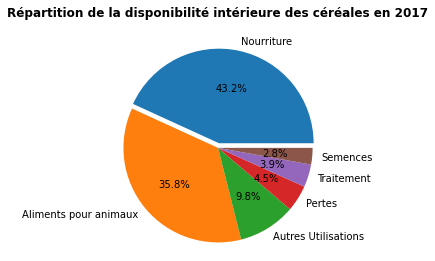

In [47]:
# Création de Camembert

# Construire un DataFrame
data = {"Label" : LabelCol, "DispoCereal" : DispCol_Cereal}
DispoCol = pd.DataFrame(data).sort_values(by="DispoCereal", ascending=False)

plt.pie(x=DispoCol["DispoCereal"], labels = DispoCol["Label"], autopct = "%1.1f%%", explode = (0.05,0,0,0,0,0), shadow=False)
plt.title("Répartition de la disponibilité intérieure des céréales en 2017",fontweight="bold", pad=20)
plt.axis("equal")
plt.savefig("Camembert_DispCereal.jpg")
plt.show()


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [48]:
#Création de la colonne proportion par pays
popSousNut2017["Proportion sous-alimentée %"] = popSousNut2017["sous_nutrition"]/popSousNut2017["Population"]*100

In [49]:
#Affichage après trie des 10 pires pays
popSousNut2017.sort_values("Proportion sous-alimentée %", ascending=False).head(10)

,Zone,Année_x,Population,Année_y,sous_nutrition,Proportion sous-alimentée %
78,Haïti,2017,10982366.0,2016-2018,5300000.0,48.259182
157,République populaire démocratique de Corée,2017,25429825.0,2016-2018,12000000.0,47.188685
108,Madagascar,2017,25570512.0,2016-2018,10500000.0,41.062924
103,Libéria,2017,4702226.0,2016-2018,1800000.0,38.279742
100,Lesotho,2017,2091534.0,2016-2018,800000.0,38.249438
183,Tchad,2017,15016753.0,2016-2018,5700000.0,37.957606
161,Rwanda,2017,11980961.0,2016-2018,4200000.0,35.055619
121,Mozambique,2017,28649018.0,2016-2018,9400000.0,32.810898
186,Timor-Leste,2017,1243258.0,2016-2018,400000.0,32.173531
0,Afghanistan,2017,36296113.0,2016-2018,10500000.0,28.928718


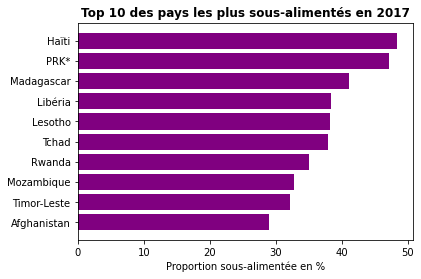

In [50]:
# Création d'un histogramme horizontal

# Raccourcir les noms
popSousNut2017.loc[popSousNut2017["Zone"]=="République populaire démocratique de Corée","Zone"]="PRK*"

popSousNut10 = popSousNut2017.sort_values("Proportion sous-alimentée %", ascending=False).head(10)
popSousNut10_sort = popSousNut10.sort_values("Proportion sous-alimentée %", ascending=True)
plt.barh(popSousNut10_sort["Zone"],popSousNut10_sort["Proportion sous-alimentée %"], color="purple")
plt.xlabel("Proportion sous-alimentée en %")
plt.title("Top 10 des pays les plus sous-alimentés en 2017", fontweight="bold")
plt.savefig("Barre_Top10SousNut.jpg",bbox_inches='tight')

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [51]:
#Calcul du total de l'aide alimentaire par pays
aideAlimentPays = aideAlimentaire.groupby("Zone")["Valeur"].sum().reset_index()


In [52]:
#Affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
display(aideAlimentPays.sort_values("Valeur",ascending=False).head(10))

,Zone,Valeur
50,République arabe syrienne,1858943000
75,Éthiopie,1381294000
70,Yémen,1206484000
61,Soudan du Sud,695248000
60,Soudan,669784000
30,Kenya,552836000
3,Bangladesh,348188000
59,Somalie,292678000
53,République démocratique du Congo,288502000
43,Niger,276344000


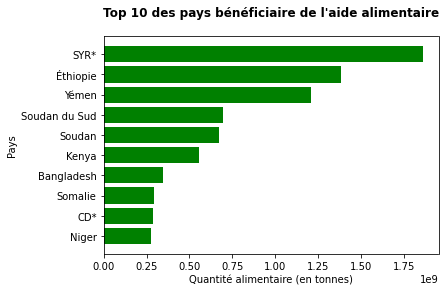

In [53]:
#Création d'un graphique en barre

# Raccourir les noms
aideAlimentPays.loc[aideAlimentPays["Zone"]=="République démocratique du Congo","Zone"]="CD*"
aideAlimentPays.loc[aideAlimentPays["Zone"]=="République arabe syrienne","Zone"]="SYR*"

# Données des Top10 bénéficiaires
aideAlimentPays_Top10 = aideAlimentPays.sort_values("Valeur",ascending=False).head(10)
aideAlimentPays10_sort = aideAlimentPays_Top10.sort_values("Valeur", ascending=True)

# Graphique
plt.barh(aideAlimentPays10_sort["Zone"],aideAlimentPays10_sort["Valeur"], color="green")
plt.xlabel('Quantité alimentaire (en tonnes)')
plt.ylabel('Pays')
plt.title("Top 10 des pays bénéficiaire de l\'aide alimentaire",fontweight="bold", pad= 20)
#plt.xticks(rotation=90)
plt.savefig("Barre_Top10PaysBenef.jpg",bbox_inches="tight")
plt.show()


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [54]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année
aideAlimentPaysAnn = aideAlimentaire.groupby(["Zone","Année"])["Valeur"].sum().reset_index()
aideAlimentPaysAnn.loc[aideAlimentPaysAnn["Zone"]=="République arabe syrienne","Zone"]="SYR*"


In [55]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
listPays = ["SYR*","Éthiopie","Yémen","Soudan du Sud","Soudan"]


In [56]:
#On filtre sur le dataframe avec notre liste
aideAlimentPaysPlus = aideAlimentPays.loc[aideAlimentPays["Zone"].isin(listPays),:].sort_values("Valeur",ascending=False)
display(aideAlimentPaysPlus)

,Zone,Valeur
50,SYR*,1858943000
75,Éthiopie,1381294000
70,Yémen,1206484000
61,Soudan du Sud,695248000
60,Soudan,669784000


In [57]:
# Affichage des pays avec l'aide alimentaire par année
aideAlimentPaysEvo = aideAlimentPaysAnn.loc[aideAlimentPaysAnn["Zone"].isin(listPays),:].sort_values("Année",ascending=True)
display(aideAlimentPaysEvo.head(5))

,Zone,Année,Valeur
157,SYR*,2013,563566000
225,Éthiopie,2013,591404000
214,Yémen,2013,264764000
189,Soudan,2013,330230000
192,Soudan du Sud,2013,196330000


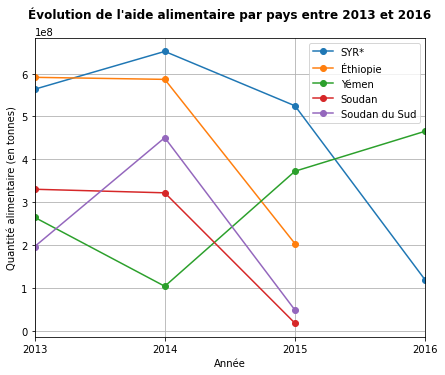

In [58]:
# Création d'un graphique de courbe
plt.figure(figsize = (7, 5.5))

# Superpose les graphiques
for zone in aideAlimentPaysEvo["Zone"].unique():
    dataZone = aideAlimentPaysEvo[aideAlimentPaysEvo["Zone"] == zone]
    dataZone_sort = dataZone.sort_values("Année",ascending=True)
    plt.plot(dataZone_sort["Année"], dataZone_sort["Valeur"], label=zone, marker='o')

# Graphique
plt.xlabel("Année")
plt.ylabel("Quantité alimentaire (en tonnes)")
plt.xlim(2013,2016)
plt.xticks([2013,2014,2015,2016])
plt.grid(True)
plt.title("Évolution de l'aide alimentaire par pays entre 2013 et 2016",fontweight="bold",pad=20)
plt.legend(loc="best")
plt.savefig("Courbe_AideAliment20132016.jpg",bbox_inches='tight')
plt.show()


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [59]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispoAlimentPays = dispoAlimentaire.groupby("Zone")["Disponibilité alimentaire (Kcal/personne/jour)"].sum().reset_index()

In [60]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne
dispoAlimentPays["Disponibilité alimentaire (Kcal/personne)"] = 365*dispoAlimentPays["Disponibilité alimentaire (Kcal/personne/jour)"]
dispoAlimentPays.sort_values("Disponibilité alimentaire (Kcal/personne)").head(10)

,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire (Kcal/personne)
128,République centrafricaine,1879.0,685835.0
166,Zambie,1924.0,702260.0
91,Madagascar,2056.0,750440.0
0,Afghanistan,2087.0,761755.0
65,Haïti,2089.0,762485.0
133,République populaire démocratique de Corée,2093.0,763945.0
151,Tchad,2109.0,769785.0
167,Zimbabwe,2113.0,771245.0
114,Ouganda,2126.0,775990.0
154,Timor-Leste,2129.0,777085.0


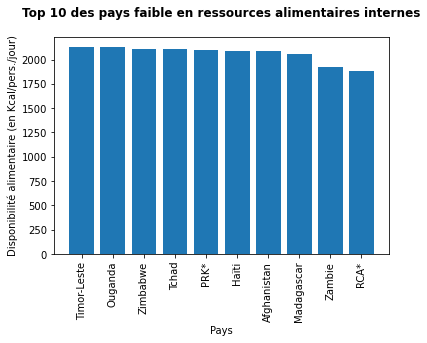

In [61]:
# Graphique de barre
dispoAlimentPays.loc[dispoAlimentPays["Zone"]=="République populaire démocratique de Corée","Zone"]="PRK*"
dispoAlimentPays.loc[dispoAlimentPays["Zone"]=="République centrafricaine","Zone"]="RCA*"

# Construire DataFrame des Top10 faible en disponibilité
dispoAlimentPays_Moins10 = dispoAlimentPays.sort_values("Disponibilité alimentaire (Kcal/personne)").head(10)
dispoAlimentPays10_sort = dispoAlimentPays_Moins10.sort_values("Disponibilité alimentaire (Kcal/personne/jour)", ascending=False)
plt.bar(dispoAlimentPays10_sort["Zone"],dispoAlimentPays10_sort["Disponibilité alimentaire (Kcal/personne/jour)"])
plt.xlabel("Pays")
plt.ylabel('Disponibilité alimentaire (en Kcal/pers./jour)')
plt.title("Top 10 des pays faible en ressources alimentaires internes", fontweight="bold",pad=20)
plt.xticks(rotation=90)
plt.savefig("Barre_10FaibleDispo.jpg",bbox_inches="tight")
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [62]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne
dispoAlimentPays.sort_values("Disponibilité alimentaire (Kcal/personne)",ascending=False).head(10)

,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire (Kcal/personne)
11,Autriche,3770.0,1376050.0
16,Belgique,3737.0,1364005.0
159,Turquie,3708.0,1353420.0
171,États-Unis d'Amérique,3682.0,1343930.0
74,Israël,3610.0,1317650.0
72,Irlande,3602.0,1314730.0
75,Italie,3578.0,1305970.0
89,Luxembourg,3540.0,1292100.0
168,Égypte,3518.0,1284070.0
4,Allemagne,3503.0,1278595.0


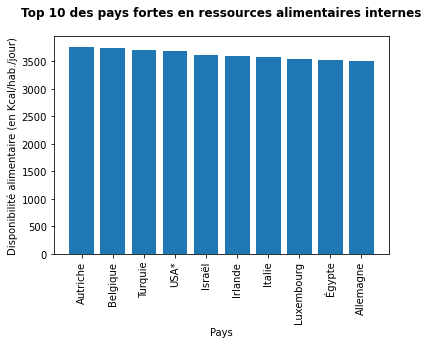

In [63]:
# Création de grahique en barre
dispoAlimentPays.loc[dispoAlimentPays["Zone"]=="États-Unis d'Amérique","Zone"]="USA*"

# DataFrame des Top10 pays d'aide alimentaire
dispoAlimentPays_Top10 = dispoAlimentPays.sort_values("Disponibilité alimentaire (Kcal/personne)",ascending=False).head(10)
dispoAlimentPays10_sort = dispoAlimentPays_Top10.sort_values("Disponibilité alimentaire (Kcal/personne/jour)", ascending=False)
plt.bar(dispoAlimentPays10_sort["Zone"],dispoAlimentPays10_sort["Disponibilité alimentaire (Kcal/personne/jour)"])
plt.xlabel('Pays')
plt.ylabel('Disponibilité alimentaire (en Kcal/hab./jour)')
plt.title("Top 10 des pays fortes en ressources alimentaires internes", fontweight="bold", pad=20)
plt.xticks(rotation=90)
plt.savefig("Barre_Top10Dispo.jpg",bbox_inches="tight")
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [64]:
#création d'un dataframe avec uniquement la Thaïlande
popThailande2017 = population.loc[(population["Zone"]=="Thaïlande") & (population["Année"]==2017),:]
dispoAlimentThail = dispoAlimentaire.loc[dispoAlimentaire["Zone"]=="Thaïlande",:]
sousNutrition2017 = sousNutrition.loc[sousNutrition["Année"]=="2016-2018",:]

display(dispoAlimentThail.sort_values("Disponibilité intérieure", ascending=False).head(10))


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
13843,Thaïlande,"Sucre, canne",vegetale,0.000000e+00,0.000000e+00,49.0,61.11,0.33,0.17,100096.0,0.000000e+00,0.000000e+00,4.095000e+09,1.001000e+09,1.000960e+11,0.0,9.500000e+10,0.000000e+00
13837,Thaïlande,Riz (Eq Blanchi),vegetale,2.405000e+09,0.000000e+00,1139.0,114.57,2.50,19.97,13605.0,6.860000e+09,5.000000e+07,7.677000e+09,1.786000e+09,2.405400e+10,606000000.0,1.130000e+09,-3.638000e+09
13809,Thaïlande,Manioc,vegetale,1.800000e+09,2.081000e+09,40.0,13.00,0.05,0.14,6264.0,2.521400e+10,1.250000e+09,8.710000e+08,1.511000e+09,3.022800e+10,0.0,0.000000e+00,0.000000e+00
13810,Thaïlande,Maïs,vegetale,3.724000e+09,0.000000e+00,95.0,10.16,1.04,2.46,4678.0,5.910000e+08,2.060000e+08,6.810000e+08,1.050000e+08,5.063000e+09,24000000.0,1.440000e+08,0.000000e+00
13783,Thaïlande,"Fruits, Autres",vegetale,0.000000e+00,0.000000e+00,63.0,57.56,0.56,0.72,3791.0,2.671000e+09,2.610000e+08,3.857000e+09,3.960000e+08,6.141000e+09,0.0,6.000000e+06,6.000000e+07
13807,Thaïlande,"Légumes, Autres",vegetale,0.000000e+00,0.000000e+00,36.0,47.86,0.32,1.85,3557.0,4.640000e+08,3.780000e+08,3.207000e+09,3.500000e+08,3.643000e+09,0.0,0.000000e+00,0.000000e+00
13841,Thaïlande,Sucre Eq Brut,vegetale,0.000000e+00,0.000000e+00,368.0,37.69,0.00,0.00,2527.0,6.462000e+09,2.500000e+07,2.526000e+09,0.000000e+00,1.002400e+10,0.0,1.000000e+06,-1.060000e+09
13806,Thaïlande,Lait - Excl Beurre,animale,0.000000e+00,1.470000e+08,45.0,29.35,1.74,2.46,2147.0,2.000000e+08,1.241000e+09,1.967000e+09,3.300000e+07,1.095000e+09,0.0,0.000000e+00,1.100000e+07
13769,Thaïlande,Bière,vegetale,0.000000e+00,0.000000e+00,41.0,30.44,0.00,0.42,2040.0,2.490000e+08,1.700000e+07,2.040000e+09,0.000000e+00,2.273000e+09,0.0,0.000000e+00,0.000000e+00
13770,Thaïlande,Blé,vegetale,1.130000e+09,0.000000e+00,76.0,10.93,0.23,2.18,1882.0,2.370000e+08,2.118000e+09,7.330000e+08,0.000000e+00,2.000000e+06,0.0,2.000000e+07,0.000000e+00


In [65]:
#Calcul de la sous nutrition en Thaïlande
popSousNutThail = pd.merge(popThailande2017, sousNutrition2017, on="Zone",how="inner")

print("Le taux de sous-nutrition en 2017 à Thaïlande est de: {:2.1f}%".format(popSousNutThail["sous_nutrition"].sum()*100/popSousNutThail["Population"].sum()))

Le taux de sous-nutrition en 2017 à Thaïlande est de: 9.0%


In [66]:
# On calcule la proportion exportée, importée et perdues en fonction de la production
ImpExpThail = dispoAlimentThail.loc[dispoAlimentaire["Produit"]=="Manioc", ["Exportations - Quantité","Importations - Quantité", "Production", "Pertes"]]

propExp = ImpExpThail["Exportations - Quantité"].sum()/ImpExpThail["Production"].sum()*100
propImp = ImpExpThail["Importations - Quantité"].sum()/ImpExpThail["Production"].sum()*100
propPerte = ImpExpThail["Pertes"].sum()/ImpExpThail["Production"].sum()*100

print("La proportion d'exportation en Thaïlande est de {e:2.1f}% et d'importation est de {i:2.1f}% et de pertes {p:2.1f}%".format(e=propExp, i=propImp, p=propPerte))

La proportion d'exportation en Thaïlande est de 83.4% et d'importation est de 4.1% et de pertes 5.0%


In [67]:
# Disponibilité alimentaire de Manioc par habitant et par jour en Kcal
dispoManiocThail = dispoAlimentThail.loc[dispoAlimentaire["Produit"]=="Manioc", :]
dispoManiocInt = dispoManiocThail["Nourriture"].sum()+dispoManiocThail["Pertes"].sum()+dispoManiocThail["Semences"].sum()+dispoManiocThail["Traitement"].sum()+dispoManiocThail["Aliments pour animaux"].sum()+dispoManiocThail["Autres Utilisations"].sum()

print("La disponibilité par habitant à Manioc est de : {:,.1f} Kcal par an".format(365*dispoManiocThail["Disponibilité alimentaire (Kcal/personne/jour)"].sum()))


La disponibilité par habitant à Manioc est de : 14,600.0 Kcal par an


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

L'intérêt de cette analyse complémentaire est de comprendre l'impact du commerce sur l'alimentation de la population mondiale. Les constats faits sur le manioc en Thaïlande représentent-ils un phénomène largement répandu ou un cas particulier ?

In [68]:
#Construire DataFrame pour avoir le graphique

# Chargement du fichier sous-nutrition & retraitement pour avoir les bons chiffres et pour l'année 2017
sousNutrition = pd.read_csv('sous_nutrition.csv')
sousNutrition["Valeur"] = pd.to_numeric(sousNutrition["Valeur"], errors="coerce") # sans remplacer les NaN
sousNutrition = sousNutrition.rename(columns = {"Valeur" : "sous_nutrition"})
sousNutrition["sous_nutrition"] *= 1000000
sousNut2017 = sousNutrition.loc[sousNutrition["Année"]=="2016-2018"]

# Population en 2017
pop2017 = population.loc[population["Année"]==2017,]

# Regroupement des données par Pays
dispoAlimentaire = dispoAlimentaire.groupby("Zone").agg({"Disponibilité alimentaire (Kcal/personne/jour)" : "sum",
                                                         "Disponibilité intérieure" : "sum", "Exportations - Quantité" : "sum",
                                                         "Importations - Quantité" : "sum", "Production" : "sum",
                                                         "Variation de stock":"sum"}).reset_index()

#Jointure des données Disponibilité alimentaire et Sous-nutrition en 2017
dispoSousNut2017 = pd.merge(dispoAlimentaire,sousNut2017,on="Zone", how="inner")
dispoSousPop2017 = pd.merge(dispoSousNut2017,pop2017,on="Zone", how="inner")
display(dispoSousPop2017.head(10))


,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,Variation de stock,Année_x,sous_nutrition,Année_y,Population
0,Afghanistan,2087.0,13515.0,2.780000e+08,2.988000e+09,1.117100e+10,-3.680000e+08,2016-2018,10500000.0,2017,36296113.0
1,Afrique du Sud,3020.0,61256.0,1.167400e+10,7.517000e+09,6.326300e+10,2.153000e+09,2016-2018,3100000.0,2017,57009756.0
2,Albanie,3188.0,4758.0,9.400000e+07,9.330000e+08,3.964000e+09,-4.500000e+07,2016-2018,100000.0,2017,2884169.0
3,Algérie,3293.0,42630.0,6.550000e+08,1.740300e+10,2.635900e+10,-4.790000e+08,2016-2018,1300000.0,2017,41389189.0
4,Allemagne,3503.0,162275.0,5.743100e+10,6.535300e+10,1.545470e+11,-1.920000e+08,2016-2018,NaN,2017,82658409.0
5,Angola,2474.0,32029.0,2.300000e+07,4.416000e+09,2.885700e+10,-1.228000e+09,2016-2018,5800000.0,2017,29816766.0
6,Antigua-et-Barbuda,2416.0,79.0,0.000000e+00,6.300000e+07,2.000000e+07,-7.000000e+06,2016-2018,NaN,2017,95426.0
7,Arabie saoudite,3255.0,31274.0,4.707000e+09,2.772600e+10,8.878000e+09,-6.280000e+08,2016-2018,1600000.0,2017,33101179.0
8,Argentine,3226.0,114369.0,5.233300e+10,1.212000e+09,1.761240e+11,-1.063200e+10,2016-2018,1500000.0,2017,43937140.0
9,Arménie,2924.0,4388.0,1.490000e+08,8.180000e+08,3.819000e+09,-9.500000e+07,2016-2018,NaN,2017,2944791.0


count    84.000000
mean      0.141265
std       0.111322
min       0.028159
25%       0.056605
50%       0.099995
75%       0.193149
max       0.482592
dtype: float64


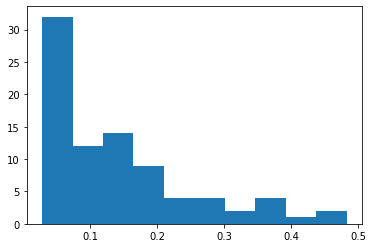

In [69]:
# La distribution de sous-nutrition au niveau mondial en 2017

expSousNut2017 = dispoSousPop2017["Exportations - Quantité"]
impSousNut2017 = dispoSousPop2017["Importations - Quantité"]
prodSousNut2017 = dispoSousPop2017["Production"]
ptgsousNutrition2017 = dispoSousPop2017["sous_nutrition"]/dispoSousPop2017["Population"]

print(ptgsousNutrition2017.describe())
plt.hist(ptgsousNutrition2017)

# Délimtation en 3 classes d'état de sous-nutrition selon les observations
minptgSousNut = min(ptgsousNutrition2017)
q1ptgSousNut = ptgsousNutrition2017.quantile(q=0.25)
medianptgSousNut = ptgsousNutrition2017.quantile(q=0.5)
q3ptgSousNut = ptgsousNutrition2017.quantile(q=0.75)
maxptgSousNut =max(ptgsousNutrition2017)


In [70]:
# Etudier la relation entre l'exportation/ l'importation & la sous-nutrition - Exportation et Importation par rapport à la production

# Définition des conditions et délimiter les classes
conditions = [
    (ptgsousNutrition2017 >= 0) & (ptgsousNutrition2017 <= q1ptgSousNut),
    (ptgsousNutrition2017 > q1ptgSousNut) & (ptgsousNutrition2017 <= q3ptgSousNut),
    (ptgsousNutrition2017 < maxptgSousNut)
]

# Définir les 3 classe : Saine, Insuffisant et Extrêmement insuffisant
choices = ['Sain', 'Insuffisant', 'Extrême insuffisant']

# Utilisation de np.select pour appliquer les conditions à une nouvelle colonne Etat Sous-nutrition
import numpy as np
dispoSousNut2017["Etat Sous-nutrition"] = np.select(conditions, choices, default='Non défini')
display(dispoSousNut2017.head(10))

# Distribution des pays selon les classes
print("Distribution des pays selon les classes : ")
print(dispoSousNut2017["Etat Sous-nutrition"].value_counts())

,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,Variation de stock,Année,sous_nutrition,Etat Sous-nutrition
0,Afghanistan,2087.0,13515.0,2.780000e+08,2.988000e+09,1.117100e+10,-3.680000e+08,2016-2018,10500000.0,Extrême insuffisant
1,Afrique du Sud,3020.0,61256.0,1.167400e+10,7.517000e+09,6.326300e+10,2.153000e+09,2016-2018,3100000.0,Sain
2,Albanie,3188.0,4758.0,9.400000e+07,9.330000e+08,3.964000e+09,-4.500000e+07,2016-2018,100000.0,Sain
3,Algérie,3293.0,42630.0,6.550000e+08,1.740300e+10,2.635900e+10,-4.790000e+08,2016-2018,1300000.0,Sain
4,Allemagne,3503.0,162275.0,5.743100e+10,6.535300e+10,1.545470e+11,-1.920000e+08,2016-2018,NaN,Non défini
5,Angola,2474.0,32029.0,2.300000e+07,4.416000e+09,2.885700e+10,-1.228000e+09,2016-2018,5800000.0,Extrême insuffisant
6,Antigua-et-Barbuda,2416.0,79.0,0.000000e+00,6.300000e+07,2.000000e+07,-7.000000e+06,2016-2018,NaN,Non défini
7,Arabie saoudite,3255.0,31274.0,4.707000e+09,2.772600e+10,8.878000e+09,-6.280000e+08,2016-2018,1600000.0,Sain
8,Argentine,3226.0,114369.0,5.233300e+10,1.212000e+09,1.761240e+11,-1.063200e+10,2016-2018,1500000.0,Sain
9,Arménie,2924.0,4388.0,1.490000e+08,8.180000e+08,3.819000e+09,-9.500000e+07,2016-2018,NaN,Non défini


Distribution des pays selon les classes : 
Non défini             89
Insuffisant            42
Sain                   21
Extrême insuffisant    20
Name: Etat Sous-nutrition, dtype: int64


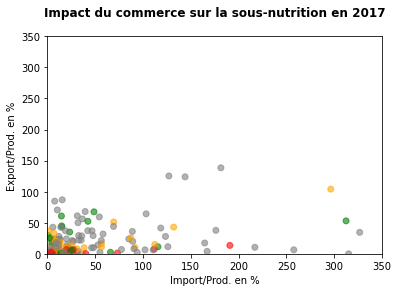

In [71]:
# Etudier la relation entre l'exportation/ l'importation & la sous-nutrition
# Création de graphique de nuage des points

color_map = {"Sain": "green", "Insuffisant": "orange", "Extrême insuffisant": "red"}

# Mapper les couleurs sur la colonne 'Etat Sous-nutrition'
####dispoSousNut2017 = dispoSousNut2017.loc[dispoSousNut2017["Etat Sous-nutrition"]=="Extrême insuffisant",]
colors = dispoSousNut2017["Etat Sous-nutrition"].map(color_map).fillna("gray")

plt.scatter((dispoSousNut2017["Importations - Quantité"]/dispoSousNut2017["Production"])*100,
            (dispoSousNut2017["Exportations - Quantité"]/dispoSousNut2017["Production"])*100,
            alpha=0.6, c=colors)
plt.xlabel("Import/Prod. en %")
plt.ylabel("Export/Prod. en %")
plt.xlim(0, 350)
plt.ylim(0, 350)

plt.title("Impact du commerce sur la sous-nutrition en 2017", fontweight = "bold", pad = 20)
plt.savefig("ExpImpSous.jpg",bbox_inches="tight")


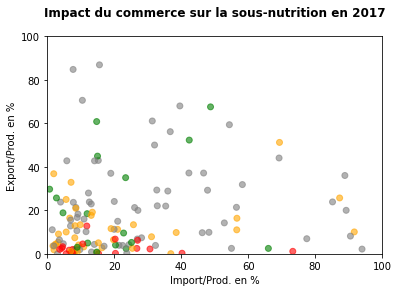

In [72]:
# Zoom sur l'échelle inférieur (à 100%)
plt.scatter((dispoSousNut2017["Importations - Quantité"]/dispoSousNut2017["Production"])*100,
            (dispoSousNut2017["Exportations - Quantité"]/dispoSousNut2017["Production"])*100,
            alpha=0.6, c=colors)
plt.xlabel("Import/Prod. en %")
plt.ylabel("Export/Prod. en %")
plt.xlim(0, 100)
plt.ylim(0, 100)

plt.title("Impact du commerce sur la sous-nutrition en 2017", fontweight = "bold", pad = 20)
plt.savefig("ExpImpSousZoom.jpg",bbox_inches="tight")



Fin de NoteBook Python